# 03 — Sector Rotation EDA

Explores `src/features/sector_rotation.py`'s output: which CSE sectors
outperform in each detected market regime, 2021-2025 only (see the
README's "Project scope" section for why the pre-2016 sector taxonomy
isn't mixed in here).

Run `python -m src.features.sector_rotation` first if the processed
files don't exist yet.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

PROCESSED = Path("../data/processed")
merged = pd.read_parquet(PROCESSED / "sector_rotation_merged.parquet")
ranking = pd.read_parquet(PROCESSED / "sector_rotation_ranking.parquet")

print("merged (monthly sector return x regime):", merged.shape)
print("ranking (regime x sector average):", ranking.shape)
merged.head()

merged (monthly sector return x regime): (1167, 6)
ranking (regime x sector average): (62, 4)


,date,sector,market_cap,mom_return,month,regime
0,2021-02-01,Automobiles & Components,6.343560e+09,-0.162420,2021-02-01,Crisis / Sell-off
1,2021-03-01,Automobiles & Components,6.271200e+09,-0.011407,2021-03-01,Crisis / Sell-off
2,2021-04-01,Automobiles & Components,6.753600e+09,0.076923,2021-04-01,Volatile Recovery
3,2021-05-01,Automobiles & Components,6.834000e+09,0.011905,2021-05-01,Crisis / Sell-off
4,2021-06-01,Automobiles & Components,6.777720e+09,-0.008235,2021-06-01,Bull / Stable Growth


## How many months of data does each regime actually have?

Thin coverage matters here -- a sector's average return in a regime that
only occurred for 2-3 months is much noisier than one with 20+ months,
even though the ranking table gives both a single "average return"
number.

In [2]:
ranking.groupby("regime")["n_months"].agg(["min", "median", "max"])

,min,median,max
regime,,,
Bull / Stable Growth,9,24.0,24
Crisis / Sell-off,12,15.0,15
Volatile Recovery,9,20.0,20


## Top / bottom sectors per regime

In [3]:
MIN_MONTHS = 3  # matches the README's stated threshold for sector rotation reliability

for regime, group in ranking.groupby("regime"):
    reliable = group[group["n_months"] >= MIN_MONTHS].sort_values("avg_monthly_return", ascending=False)
    print(f"\n=== {regime} (sectors with >= {MIN_MONTHS} months of data) ===")
    print("Top 3:")
    print(reliable.head(3)[["sector", "avg_monthly_return", "n_months"]].to_string(index=False))
    print("Bottom 3:")
    print(reliable.tail(3)[["sector", "avg_monthly_return", "n_months"]].to_string(index=False))


=== Bull / Stable Growth (sectors with >= 3 months of data) ===
Top 3:
                     sector  avg_monthly_return  n_months
                  Retailing            0.498203        24
             Transportation            0.303183        24
Consumer Durables & Apparel            0.025212        24
Bottom 3:
             sector  avg_monthly_return  n_months
          Insurance           -0.012024        24
  Telecommunication           -0.013575        24
Software & Services           -0.034297        21

=== Crisis / Sell-off (sectors with >= 3 months of data) ===
Top 3:
                sector  avg_monthly_return  n_months
   Software & Services            4.664827        12
     Telecommunication            0.440419        15
Diversified Financials            0.321040        15
Bottom 3:
                  sector  avg_monthly_return  n_months
               Materials            0.017726        15
                   Banks           -0.002355        15
Automobiles & Components      

## Visualizing rotation: top 5 sectors by regime

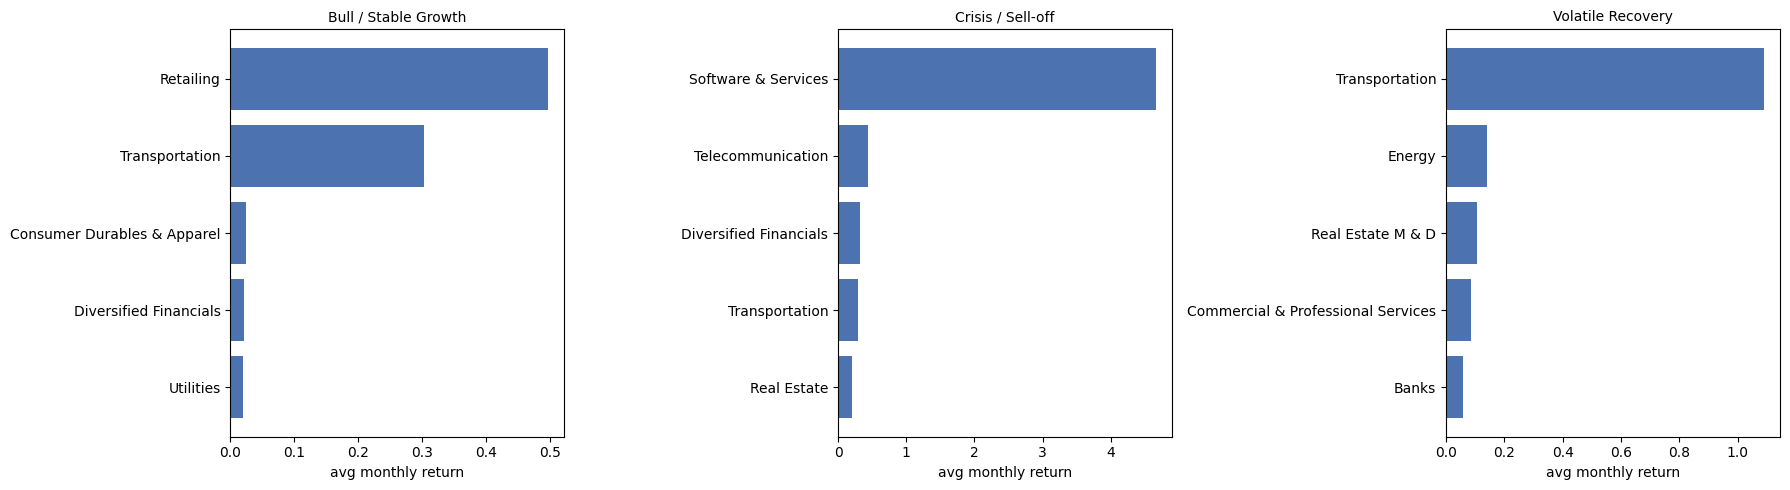

In [4]:
fig, axes = plt.subplots(1, len(ranking["regime"].unique()), figsize=(18, 5), sharey=False)
for ax, (regime, group) in zip(axes, ranking.groupby("regime")):
    reliable = group[group["n_months"] >= MIN_MONTHS].sort_values("avg_monthly_return", ascending=False).head(5)
    ax.barh(reliable["sector"], reliable["avg_monthly_return"], color="#4c72b0")
    ax.set_title(regime, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("avg monthly return")
plt.tight_layout()
plt.show()

## Caution: outliers from thin market-cap sectors

The README explicitly warns that some thin sectors show large % swings
from a small market-cap base. Check for extreme month-over-month moves
in the underlying merged table.

In [5]:
extreme = merged[merged["mom_return"].abs() > 0.5].sort_values("mom_return", ascending=False)
print(f"{len(extreme)} sector-months with a >50% month-over-month swing")
extreme[["date", "sector", "market_cap", "mom_return", "regime"]].head(10)

52 sector-months with a >50% month-over-month swing


,date,sector,market_cap,mom_return,regime
956,2023-03-01,Software & Services,2.554323e+11,54.948696,Crisis / Sell-off
1093,2024-10-01,Transportation,1.774163e+10,20.362604,Volatile Recovery
910,2023-04-01,Retailing,5.128252e+10,11.522923,Bull / Stable Growth
1002,2022-02-01,Telecommunication,1.811365e+11,6.295514,Crisis / Sell-off
1075,2023-04-01,Transportation,3.135487e+11,6.131992,Bull / Stable Growth
366,2022-02-01,Diversified Financials,1.286428e+12,5.909590,Crisis / Sell-off
1061,2022-02-01,Transportation,5.797965e+11,5.857941,Crisis / Sell-off
838,2022-02-01,Real Estate,7.127915e+10,3.584968,Crisis / Sell-off
307,2022-02-01,Consumer Services,1.562852e+11,3.224321,Crisis / Sell-off
602,2022-02-01,Health Care Equipment & Services,9.970596e+10,3.127731,Crisis / Sell-off


These aren't errors in the same sense as the event-study outlier found
in notebook 04 -- they're real, just driven by small-base sectors where
a modest absolute change in market cap produces a large percentage
move. Worth treating with caution rather than excluding outright, since
excluding them isn't obviously more correct than keeping them; this is
flagged as a known limitation in the README rather than silently
filtered.